In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral525.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral515.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral513.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral382.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral487.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral563.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral370.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral366.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral374.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral148.jpeg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral149.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral604.png
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral73.png
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral205.jpg
/kaggle/input/vsa-data3/Main/ValMain/val/neutral/neutral507.jpg
/kaggle/input/vsa-data3/Main/ValMain/val

In [2]:
!pip install pytesseract pillow
!apt-get install -y tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pytesseract
from transformers import CLIPProcessor, CLIPModel


2025-08-22 04:35:36.239658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755837336.437208      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755837336.494707      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import pytesseract

class VSADataset(Dataset):
    def __init__(self, root_dir, processor, class_names, use_ocr=False):
        self.root_dir = root_dir
        self.processor = processor
        self.samples = []
        self.class_to_idx = {name.lower(): i for i, name in enumerate(class_names)}
        self.use_ocr = use_ocr

        # Collect all image paths + labels
        for cname in class_names:
            folder_name = next((d for d in os.listdir(root_dir) if d.lower() == cname.lower()), None)
            if folder_name is None:
                raise ValueError(f"Class folder {cname} not found in {root_dir}")

            cdir = os.path.join(root_dir, folder_name)
            for f in os.listdir(cdir):
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((os.path.join(cdir, f), self.class_to_idx[cname.lower()]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        # OCR extraction if enabled
        ocr_text = ""
        if self.use_ocr:
            ocr_text = pytesseract.image_to_string(img)
            if ocr_text.strip() == "":
                ocr_text = "no text"   # placeholder if OCR fails

        # Process image + OCR text
        inputs = self.processor(
            images=img,
            text=[ocr_text] if self.use_ocr else ["dummy"],
            return_tensors="pt",
            padding="max_length",   # ensures equal length
            truncation=True,        # truncates long text (>77 tokens)
            max_length=77
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
            "ocr_text": ocr_text
        }


In [5]:
DATA_ROOT = "/kaggle/input/vsa-data3/Main"

TRAIN_DIR = os.path.join(DATA_ROOT, "TrainMain", "validated")
VAL_DIR   = os.path.join(DATA_ROOT, "ValMain", "val")
TEST_DIR  = os.path.join(DATA_ROOT, "TestMain", "test")

CLASS_NAMES = ["negative", "neutral", "positive"]

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

train_dataset = VSADataset(TRAIN_DIR, processor, CLASS_NAMES)
val_dataset   = VSADataset(VAL_DIR, processor, CLASS_NAMES)
test_dataset  = VSADataset(TEST_DIR, processor, CLASS_NAMES)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_model = clip_model.to(DEVICE)

# Freeze base CLIP
for p in clip_model.parameters():
    p.requires_grad = False

# Feature dimensions
vision_dim = clip_model.visual_projection.out_features
text_dim   = clip_model.text_projection.out_features

# Fusion classifier
classifier = nn.Sequential(
    nn.Linear(vision_dim + text_dim, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, len(CLASS_NAMES))
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [7]:
def train_one_epoch():
    clip_model.eval()
    classifier.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for batch in train_loader:
        images = batch["pixel_values"].to(DEVICE)
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        # Extract features
        with torch.no_grad():
            vision_feats = clip_model.get_image_features(images)
            text_feats   = clip_model.get_text_features(input_ids=input_ids, attention_mask=attention_mask)

        fused = torch.cat([vision_feats, text_feats], dim=-1)

        # Train classifier
        optimizer.zero_grad()
        logits = classifier(fused)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


In [8]:
def evaluate(loader):
    clip_model.eval()
    classifier.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            images = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            # Get features
            vision_feats = clip_model.get_image_features(images)
            text_feats   = clip_model.get_text_features(input_ids=input_ids)

            # Fuse
            fused = torch.cat([vision_feats, text_feats], dim=-1)

            # Classify
            logits = classifier(fused)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc   # ✅ return both


In [13]:
# Lists to store training & validation history
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


In [14]:
best_val_acc = 0.0

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"classifier": classifier.state_dict()}, "best_clip.pt")
        print("✅ Saved best model")


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01 | Train Acc: 0.9407 | Val Acc: 0.9208
✅ Saved best model


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02 | Train Acc: 0.9472 | Val Acc: 0.9250
✅ Saved best model


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 08 | Train Acc: 0.9756 | Val Acc: 0.9333


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 09 | Train Acc: 0.9764 | Val Acc: 0.9333


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10 | Train Acc: 0.9805 | Val Acc: 0.9375
✅ Saved best model


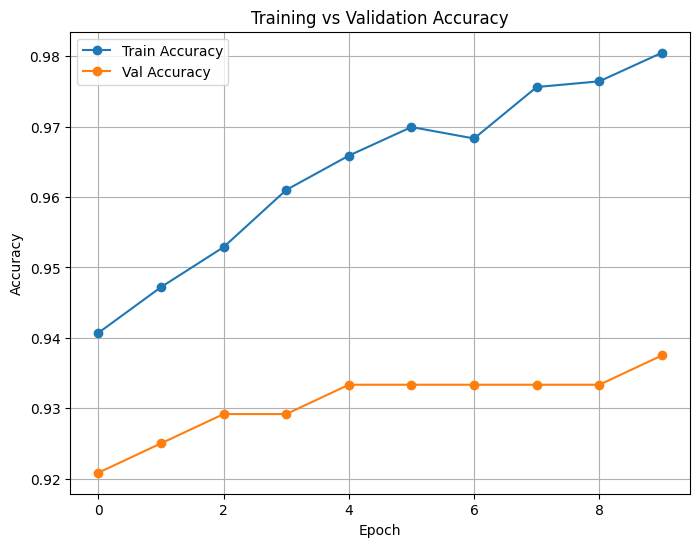

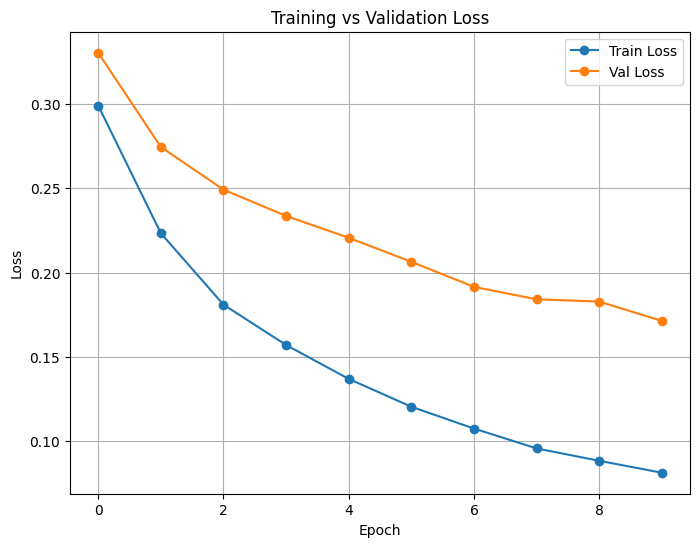

In [15]:
import matplotlib.pyplot as plt

# 🔹 Accuracy Plot
plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label="Train Accuracy", marker="o")
plt.plot(val_accuracies, label="Val Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 🔹 Loss Plot
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_with_metrics(loader):
    clip_model.eval()
    classifier.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for batch in loader:
            images = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            vision_feats = clip_model.get_image_features(images)
            text_feats   = clip_model.get_text_features(
                input_ids=input_ids, attention_mask=attention_mask
            )
            fused = torch.cat([vision_feats, text_feats], dim=-1)
            logits = classifier(fused)

            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


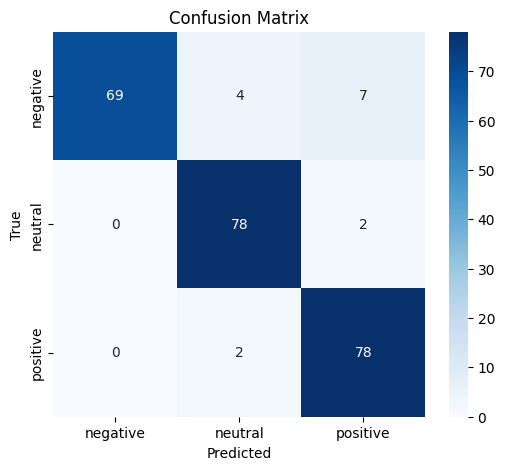


Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.86      0.93        80
     neutral       0.93      0.97      0.95        80
    positive       0.90      0.97      0.93        80

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240



In [17]:
evaluate_with_metrics(val_loader)


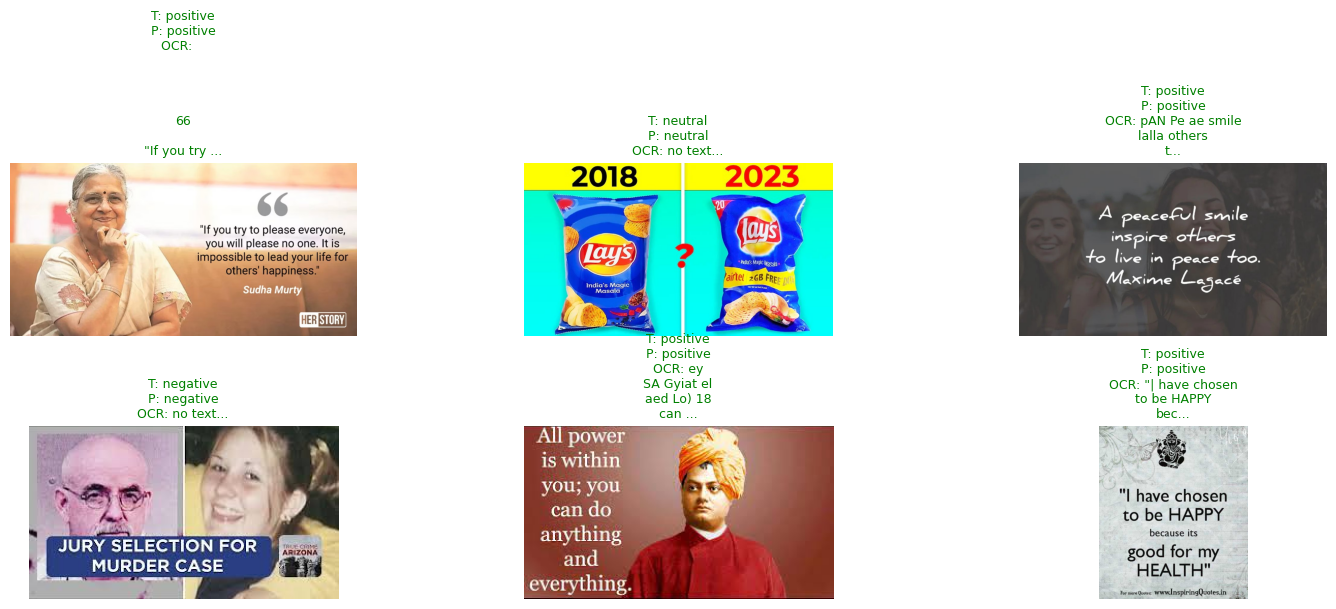

In [18]:
import random

def show_predictions(loader, num_images=6):
    clip_model.eval()
    classifier.eval()
    
    samples = random.sample(loader.dataset.samples, num_images)
    fig, axes = plt.subplots(2, num_images//2, figsize=(15,6))

    for ax, (img_path, true_label) in zip(axes.flatten(), samples):
        img = Image.open(img_path).convert("RGB")

        # OCR
        ocr_text = pytesseract.image_to_string(img)
        if ocr_text.strip() == "":
            ocr_text = "no text"

        # Preprocess
        vision_inputs = processor(images=img, return_tensors="pt").to(DEVICE)
        text_inputs = processor(text=[ocr_text], return_tensors="pt", padding=True).to(DEVICE)

        with torch.no_grad():
            vision_feats = clip_model.get_image_features(**vision_inputs)
            text_feats   = clip_model.get_text_features(**text_inputs)
            fused = torch.cat([vision_feats, text_feats], dim=-1)
            logits = classifier(fused)
            pred_idx = logits.argmax(1).item()

        ax.imshow(img)
        ax.set_title(f"T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred_idx]}\nOCR: {ocr_text[:30]}...",
                     fontsize=9, color="green" if true_label==pred_idx else "red")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run
show_predictions(test_loader, num_images=6)


In [19]:
import torch.nn as nn
from transformers import CLIPModel

# Load CLIP model
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

# ---- Unfreeze last few layers of vision encoder ----
for name, param in clip_model.vision_model.named_parameters():
    if "encoder.layers" in name:  
        # unfreeze last 2 transformer layers of vision encoder
        if any(layer_id in name for layer_id in ["10", "11"]):
            param.requires_grad = True
        else:
            param.requires_grad = False
    else:
        param.requires_grad = False  # keep everything else frozen

# Get feature dimensions
vision_dim = clip_model.visual_projection.out_features
text_dim   = clip_model.text_projection.out_features
feat_dim   = vision_dim + text_dim

# ---- Add Dropout in classifier ----
classifier = nn.Sequential(
    nn.Linear(feat_dim, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(CLASS_NAMES))
)

# Move to device
clip_model = clip_model.to(DEVICE)
classifier = classifier.to(DEVICE)

# ---- Optimizer with weight decay ----
LR = 1e-4
optimizer = torch.optim.AdamW(
    list(classifier.parameters()) + 
    [p for p in clip_model.parameters() if p.requires_grad], 
    lr=LR, weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()


In [20]:
best_val_acc = 0.0

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"classifier": classifier.state_dict()}, "best_clip.pt")
        print("✅ Saved best model")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you c

Epoch 01 | Train Acc: 0.7230 | Val Acc: 0.8958
✅ Saved best model


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02 | Train Acc: 0.9285 | Val Acc: 0.9042
✅ Saved best model


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 08 | Train Acc: 0.9578 | Val Acc: 0.9333
✅ Saved best model


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you c

Epoch 09 | Train Acc: 0.9708 | Val Acc: 0.9333


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10 | Train Acc: 0.9675 | Val Acc: 0.9333


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_with_metrics(loader):
    clip_model.eval()
    classifier.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for batch in loader:
            images = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            vision_feats = clip_model.get_image_features(images)
            text_feats   = clip_model.get_text_features(
                input_ids=input_ids, attention_mask=attention_mask
            )
            fused = torch.cat([vision_feats, text_feats], dim=-1)
            logits = classifier(fused)

            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


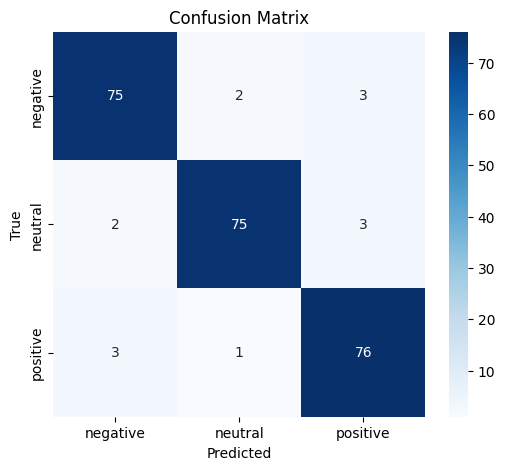


Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.94      0.94        80
     neutral       0.96      0.94      0.95        80
    positive       0.93      0.95      0.94        80

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240



In [24]:
evaluate_with_metrics(test_loader)